# 1) Load and preprocess the Bike Sharing dataset from https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset – check for missing and duplicate values and remove them when detected (set encoding='latin-1' while reading dataset otherwise it will throw error). Drop the columns which you think won't effect ouput and one-hot encode the categorical features (1 MARKS)

In [17]:
import pandas as pd
import zipfile

In [18]:
zip_path = "/content/bike+sharing+dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bike_data")

In [19]:
df = pd.read_csv("/content/bike_data/day.csv", encoding="latin-1")

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [24]:
#check missing values
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [25]:
#remove missing values if any
df.dropna(inplace=True)

In [27]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [28]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [29]:
df.drop(columns=['instant', 'dteday', 'casual', 'registered'], inplace=True)

In [30]:
categorical_cols = [
    'season', 'yr', 'mnth',
    'holiday', 'weekday',
    'workingday', 'weathersit'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [31]:
df.head()

,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,yr_1,mnth_2,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,0.344167,0.363625,0.805833,0.160446,985,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0.363478,0.353739,0.696087,0.248539,801,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.196364,0.189405,0.437273,0.248309,1349,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,0.200000,0.212122,0.590435,0.160296,1562,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,0.226957,0.229270,0.436957,0.186900,1600,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


In [32]:
df.shape

(731, 30)


# 2) Divide the data into training, validation and test sets (70%-15%-15%) and perform feature scaling (2 MARKS)

In [33]:
#separate features and target
X = df.drop(columns=['cnt'])
y = df['cnt']

In [34]:
from sklearn.model_selection import train_test_split

#split Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

#split Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [35]:
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (511, 29)
Validation set size: (110, 29)
Test set size: (110, 29)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#fit on training data
X_train_scaled = scaler.fit_transform(X_train)

#transform validation & test using same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [37]:
print("Mean of scaled training features (approx):", X_train_scaled.mean())
print("Std of scaled training features (approx):", X_train_scaled.std())

Mean of scaled training features (approx): -1.8759689949803575e-17
Std of scaled training features (approx): 0.9999999999999999



# 3) Design a neural network having N=4 hidden layers and the number of units in each hidden layer as 128, 64, 32, 16. Use the ReLU activation function in each hidden layer. What activation function should you choose for the output layer for this prediction problem? Design the model accordingly. (2 MARKS)

In [54]:
import numpy as np

def relu(z):
    return np.maximum(0, z)

def linear(z):
    return z

In [55]:
input_dim = X_train_scaled.shape[1]

layer_sizes = [input_dim, 128, 64, 32, 16, 1]

weights = {}
biases = {}

np.random.seed(42)

for i in range(len(layer_sizes) - 1):
    weights[f"W{i+1}"] = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
    biases[f"b{i+1}"] = np.zeros((1, layer_sizes[i+1]))

In [40]:
def forward_propagation(X, weights, biases):
    activations = {}
    A = X

    for i in range(1, 5):
        Z = np.dot(A, weights[f"W{i}"]) + biases[f"b{i}"]
        A = relu(Z)
        activations[f"A{i}"] = A

    #output layer
    Z_out = np.dot(A, weights["W5"]) + biases["b5"]
    y_pred = linear(Z_out)

    return y_pred, activations

In [41]:
y_pred_sample, _ = forward_propagation(X_train_scaled[:5], weights, biases)
y_pred_sample

array([[-2.72457380e-08],
       [ 7.57307496e-08],
       [-1.12582606e-07],
       [-7.84661966e-08],
       [-8.55357935e-09]])

# 4) Implement the Adam optimizer from scratch to train the above model. (6 MARKS)

In [42]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [43]:
def relu_derivative(z):
    return (z > 0).astype(float)

In [44]:
def forward_propagation(X, weights, biases):
    cache = {}
    A = X
    cache["A0"] = A

    for i in range(1, 5):
        Z = np.dot(A, weights[f"W{i}"]) + biases[f"b{i}"]
        A = relu(Z)
        cache[f"Z{i}"] = Z
        cache[f"A{i}"] = A

    Z_out = np.dot(A, weights["W5"]) + biases["b5"]
    cache["Z5"] = Z_out

    return Z_out, cache

In [70]:
def backward_propagation(X, y_scaled, y_pred, weights, cache):
    grads = {}
    m = y_scaled.shape[0]

    #output layer
    dz = (y_pred - y_scaled) / m   # dz5

    #loop from output layer to first hidden layer
    for i in reversed(range(1, 6)):
        A_prev = cache[f"A{i-1}"]

        grads[f"dW{i}"] = np.dot(A_prev.T, dz)
        grads[f"db{i}"] = np.sum(dz, axis=0, keepdims=True)

        if i > 1:
            dA_prev = np.dot(dz, weights[f"W{i}"].T)
            dz = dA_prev * relu_derivative(cache[f"Z{i-1}"])

    return grads

In [71]:
def initialize_adam(weights, biases):
    v, s = {}, {}

    for i in range(1, 6):
        v[f"W{i}"] = np.zeros_like(weights[f"W{i}"])
        s[f"W{i}"] = np.zeros_like(weights[f"W{i}"])

        v[f"b{i}"] = np.zeros_like(biases[f"b{i}"])
        s[f"b{i}"] = np.zeros_like(biases[f"b{i}"])

    return v, s

In [72]:
def adam_update(weights, biases, grads, v, s, t,
                lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):

    for i in range(1, 6):
        #momentum
        v[f"W{i}"] = beta1 * v[f"W{i}"] + (1 - beta1) * grads[f"dW{i}"]
        v[f"b{i}"] = beta1 * v[f"b{i}"] + (1 - beta1) * grads[f"db{i}"]

        #RMS
        s[f"W{i}"] = beta2 * s[f"W{i}"] + (1 - beta2) * (grads[f"dW{i}"] ** 2)
        s[f"b{i}"] = beta2 * s[f"b{i}"] + (1 - beta2) * (grads[f"db{i}"] ** 2)

        #Bias correction
        v_corr_W = v[f"W{i}"] / (1 - beta1 ** t)
        v_corr_b = v[f"b{i}"] / (1 - beta1 ** t)
        s_corr_W = s[f"W{i}"] / (1 - beta2 ** t)
        s_corr_b = s[f"b{i}"] / (1 - beta2 ** t)

        #Update
        weights[f"W{i}"] -= lr * v_corr_W / (np.sqrt(s_corr_W) + eps)
        biases[f"b{i}"] -= lr * v_corr_b / (np.sqrt(s_corr_b) + eps)

    return weights, biases

In [73]:
epochs = 200
learning_rate = 0.001

v, s = initialize_adam(weights, biases)
losses = []

for epoch in range(1, epochs + 1):
    y_pred, cache = forward_propagation(X_train_scaled, weights, biases)
    loss = mse_loss(y_train_scaled, y_pred)
    losses.append(loss)

    grads = backward_propagation(X_train_scaled, y_train_scaled, y_pred, weights, cache)

    weights, biases = adam_update(
        weights, biases, grads, v, s, epoch, lr=learning_rate
    )

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 20, Loss: 1288.4519
Epoch 40, Loss: 252.4508
Epoch 60, Loss: 92.6088
Epoch 80, Loss: 48.4755
Epoch 100, Loss: 29.6175
Epoch 120, Loss: 19.5350
Epoch 140, Loss: 13.5430
Epoch 160, Loss: 9.7773
Epoch 180, Loss: 7.3365
Epoch 200, Loss: 5.7012



# 5) Train the model with the custom implementation of Adam and plot the training and validation losses (2 MARKS)

In [74]:
#scale validation target using SAME scaler
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1))

In [75]:
epochs = 200
learning_rate = 0.001

train_losses = []
val_losses = []

v, s = initialize_adam(weights, biases)

for epoch in range(1, epochs + 1):

    #training
    y_pred_train, cache = forward_propagation(X_train_scaled, weights, biases)
    train_loss = mse_loss(y_train_scaled, y_pred_train)
    train_losses.append(train_loss)

    grads = backward_propagation(
        X_train_scaled, y_train_scaled, y_pred_train, weights, cache
    )

    weights, biases = adam_update(
        weights, biases, grads, v, s, epoch, lr=learning_rate
    )

    #validation
    y_pred_val, _ = forward_propagation(X_val_scaled, weights, biases)
    val_loss = mse_loss(y_val_scaled, y_pred_val)
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 20, Train Loss: 1.0297, Val Loss: 0.9910
Epoch 40, Train Loss: 0.9520, Val Loss: 0.9670
Epoch 60, Train Loss: 0.7551, Val Loss: 1.0882
Epoch 80, Train Loss: 0.6168, Val Loss: 0.9478
Epoch 100, Train Loss: 0.5386, Val Loss: 0.9399
Epoch 120, Train Loss: 0.4787, Val Loss: 0.9582
Epoch 140, Train Loss: 0.4353, Val Loss: 0.8485
Epoch 160, Train Loss: 0.4089, Val Loss: 0.8090
Epoch 180, Train Loss: 0.3903, Val Loss: 0.7846
Epoch 200, Train Loss: 0.3669, Val Loss: 0.7520


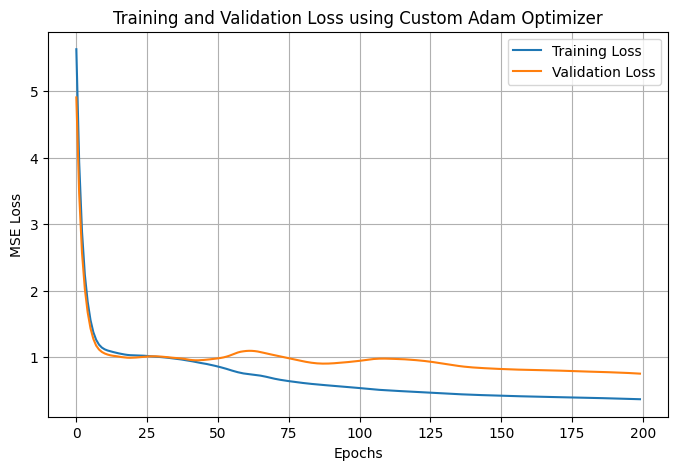

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss using Custom Adam Optimizer")
plt.legend()
plt.grid(True)
plt.show()

# 6) report the MSE and $R^2$ score obtained by the trained model on the test (2 MARKS)

In [81]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#predict on test set (model outputs are scaled-log space)
y_test_pred_scaled, _ = forward_propagation(X_test_scaled, weights, biases)

y_test_pred_log = y_scaler.inverse_transform(y_test_pred_scaled)

#inverse log-transform to get original scale
y_test_pred = np.expm1(y_test_pred_log)
y_test_true = y_test.values.reshape(-1, 1)

#compute metrics
test_mse = mean_squared_error(y_test_true, y_test_pred)
test_r2  = r2_score(y_test_true, y_test_pred)

print("Test MSE:", test_mse)
print("Test R^2 Score:", test_r2)


Test MSE: 1004993.1270229006
Test R^2 Score: 0.7354912512347462


# 7) Show a scatter plot of the predictions against the true values for the predictions for the best model that you obtained (1 MARK)

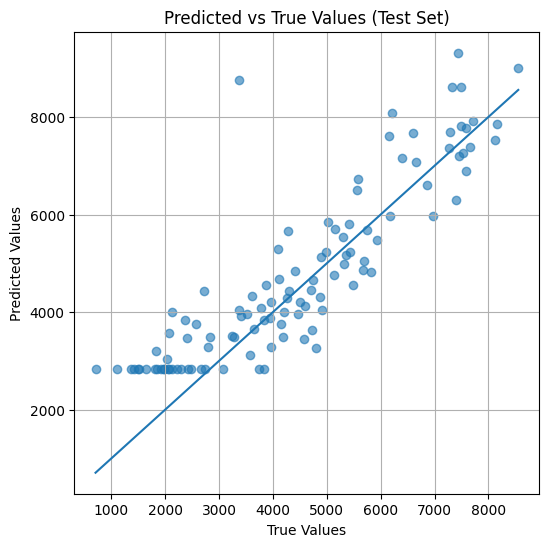

In [94]:
import numpy as np
import matplotlib.pyplot as plt

#predict on test set (best trained model)
y_test_pred_scaled, _ = forward_propagation(X_test_scaled, weights, biases)

#inverse scaling and log transform
y_test_pred_log = y_scaler.inverse_transform(y_test_pred_scaled)
y_test_pred = np.expm1(y_test_pred_log)

y_test_true = y_test.values.reshape(-1, 1)

#scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, y_test_pred, alpha=0.6)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values (Test Set)")
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()]
)
plt.grid(True)
plt.show()

# 8) Train the same model using PyTorch’s Adam optimizer, and show the same loss plots for training and validation losses. (2 MARKS)

Epoch 50, Train Loss: 0.0290, Val Loss: 0.7856
Epoch 100, Train Loss: 0.0075, Val Loss: 0.7966
Epoch 150, Train Loss: 0.0057, Val Loss: 0.7955
Epoch 200, Train Loss: 0.0054, Val Loss: 0.7953
Epoch 250, Train Loss: 0.0054, Val Loss: 0.7953
Epoch 300, Train Loss: 0.0053, Val Loss: 0.7953
Epoch 350, Train Loss: 0.0053, Val Loss: 0.7953
Epoch 400, Train Loss: 0.0053, Val Loss: 0.7953


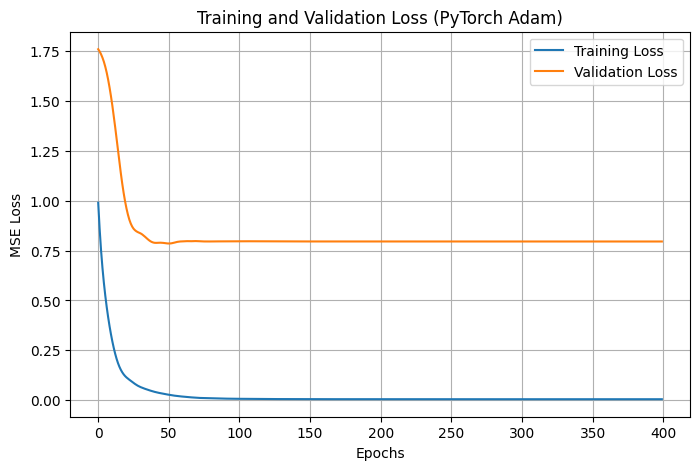

In [95]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled, dtype=torch.float32)

#model
class BikeNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = BikeNet(X_train_t.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=20
)

epochs = 400
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    train_pred = model(X_train_t)
    train_loss = criterion(train_pred, y_train_t)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t)

    scheduler.step(val_loss)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

#plot
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss (PyTorch Adam)")
plt.legend()
plt.grid(True)
plt.show()

# 9) Perform inference on the test set using the model trained with PyTorch’s implementation of the Adam optimizer. Report the MSE and $R^2$ score on the test set and show the scatter plot of predictions vs. ground truths. Compare the $R^2$  score obtained using the PyTorch implementation of Adam with your from scratch implementation. (3 MARKS)


In [91]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#Inference on test set-PyTorch Adam model
model.eval()
with torch.no_grad():
    y_test_pred_torch_scaled = model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy()

#Inverse scale + inverse log
y_test_pred_log = y_scaler.inverse_transform(y_test_pred_torch_scaled)
y_test_pred = np.expm1(y_test_pred_log)
y_test_true = y_test.values.reshape(-1, 1)

#metrics
torch_mse = mean_squared_error(y_test_true, y_test_pred)
torch_r2  = r2_score(y_test_true, y_test_pred)

print("PyTorch Adam - Test MSE:", torch_mse)
print("PyTorch Adam - Test R^2:", torch_r2)



PyTorch Adam - Test MSE: 567858.125
PyTorch Adam - Test R^2: 0.8505428433418274


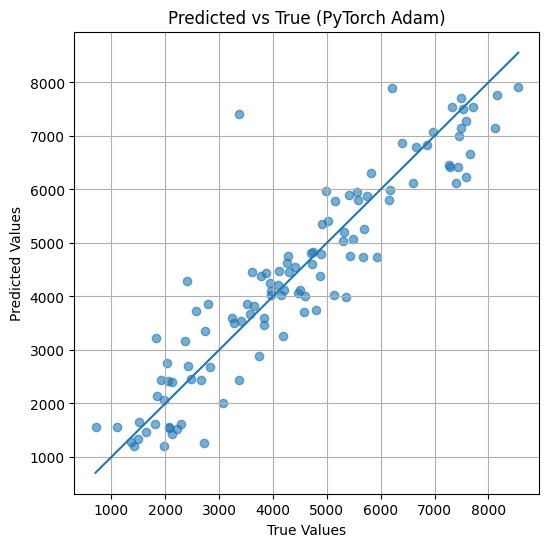

In [92]:
#Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.6)
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()]
)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True (PyTorch Adam)")
plt.grid(True)
plt.show()

In [93]:
#comparision from scratch adams
print("From-Scratch Adam - Test R^2:", scratch_r2 := test_r2)  #assumes test_r2 computed earlier
print("R^2 Improvement (PyTorch - Scratch):", torch_r2 - scratch_r2)

From-Scratch Adam - Test R^2: 0.7354912512347462
R^2 Improvement (PyTorch - Scratch): 0.11505159210708116
